# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectf** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 3** 

### **Préparation au Machine Learning**

#### **Importation des Modules**

In [12]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


In [13]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


print("Importation des modules OK")

Importation des modules OK


#### **Chargement du dataset**

In [14]:
df = pd.read_csv("../data/processed/buildings_features.csv")

print("Importation du dataset terminée.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

display(df.head())

Importation du dataset terminée.
Dimensions du dataset : 1542 lignes, 34 colonnes


,osebuildingid,datayear,buildingtype,primarypropertytype,propertyname,address,city,state,zipcode,taxparcelidentificationnumber,...,thirdlargestpropertyusetypegfa,siteenergyuse(kbtu),defaultdata,comments,usage_type,BuildingAge,ParkingRatio,BuildingRatio,IsMultiUse,NumberPropertyUses
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,NaN,7226362.5,False,NaN,Mono-usage,89,0.000000,1.000000,0,1
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,4622.0,8387933.0,False,NaN,Multi-usages,20,0.145453,0.854547,1,3
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,NaN,72587024.0,False,NaN,Mono-usage,47,0.205748,0.794252,0,1
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,NaN,6794584.0,False,NaN,Mono-usage,90,0.000000,1.000000,0,1
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,0.0,14172606.0,False,NaN,Multi-usages,36,0.353115,0.646885,1,3


### **Analyse des valeurs extrêmes**

> -  Un boxplot est utilisé afin de visualiser la présence d'éventuelles valeurs extrêmes de la variable cible.
> -  Les observations identifiées seront analysées avant toute décision de suppression, car elles peuvent correspondre à de grands bâtiments et non à des erreurs de mesure.

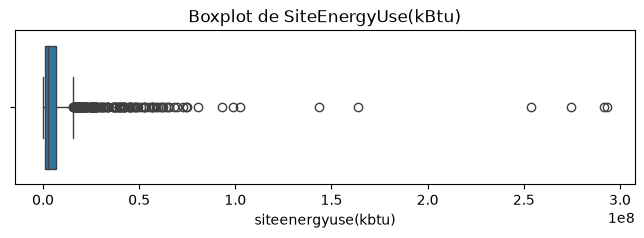

In [15]:
# Visualisation des valeurs extrêmes

plt.figure(figsize=(8, 2))

sns.boxplot(
    x=df["siteenergyuse(kbtu)"]
)

plt.title("Boxplot de SiteEnergyUse(kBtu)")

plt.show()

> -  Une matrice de corrélation de Pearson est utilisée afin d'identifier les variables numériques fortement corrélées.
> - Cette analyse permet de détecter les variables redondantes susceptibles d'apporter une information similaire au modèle

### **Analyse entre les features et la variable cible**

##### **LargestPropertyUseTypeGFA**

> - Un nuage de points est utilisé afin de visualiser la relation entre la surface principale du bâtiment (**LargestPropertyUseTypeGFA**) et la consommation énergétique (**SiteEnergyUse(kBtu)**).

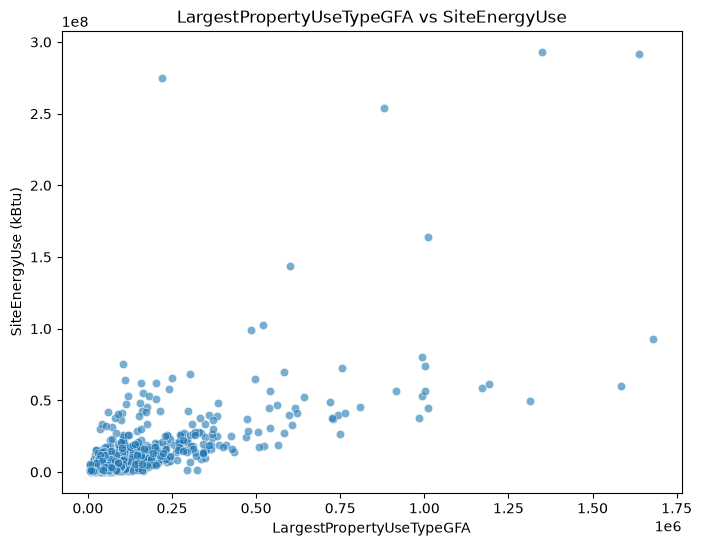

In [16]:
# Relation entre LargestPropertyUseTypeGFA et SiteEnergyUse

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="largestpropertyusetypegfa",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

plt.title("LargestPropertyUseTypeGFA vs SiteEnergyUse")
plt.xlabel("LargestPropertyUseTypeGFA")
plt.ylabel("SiteEnergyUse (kBtu)")

plt.show()

> - Le nuage de points montre une corrélation positive entre **LargestPropertyUseTypeGFA** et **SiteEnergyUse(kBtu)**.
> - Les bâtiments ayant une plus grande surface principale présentent généralement une consommation énergétique plus élevée. Quelques valeurs extrêmes sont observées, mais elles correspondent à de grands bâtiments déjà identifiés précédemment.

##### **PropertyGFATotal**

> - Un nuage de points permet de visualiser la relation entre PropertyGFATotal et la consommation énergétique SiteEnergyUse(kBtu). Cette représentation confirme une tendance croissante : les bâtiments ayant une plus grande surface présentent généralement une consommation énergétique plus élevée.

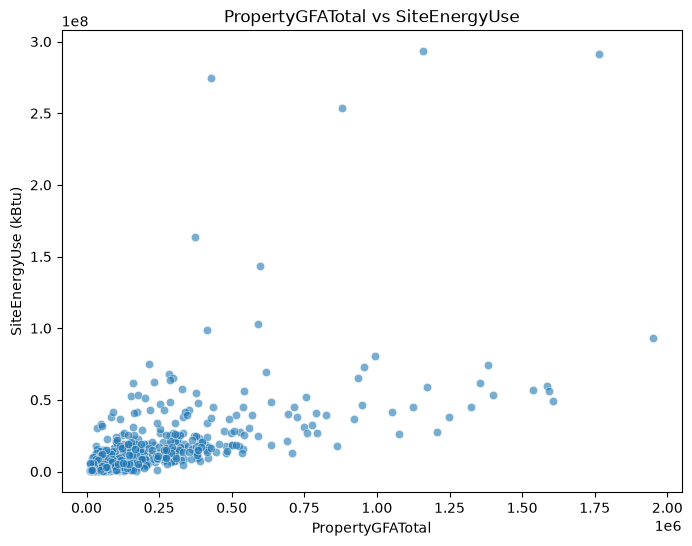

In [17]:
# Relation entre PropertyGFATotal et SiteEnergyUse

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="propertygfatotal",
    y="siteenergyuse(kbtu)",
    alpha=0.6
)

plt.title("PropertyGFATotal vs SiteEnergyUse")
plt.xlabel("PropertyGFATotal")
plt.ylabel("SiteEnergyUse (kBtu)")

plt.show()

> - Le nuage de points montre une corrélation positive entre **PropertyGFATotal** et **SiteEnergyUse(kBtu)**.
> - Les bâtiments ayant une plus grande surface totale présentent généralement une consommation énergétique plus élevée. Cette relation est cohérente avec les résultats obtenus lors de l'analyse de corrélation.

### **Préparation des variables pour le Machine Learning**

#### **Séparation des variables x / y**

> Le jeu de données est séparé en :
>  - **X** : les variables explicatives utilisées pour entraîner le modèle ;
>  - **y** : la variable cible (**SiteEnergyUse(kBtu)**).

In [18]:
# Séparation des variables explicatives (X) et de la cible (y)

X = df.drop(columns=["siteenergyuse(kbtu)"])

y = df["siteenergyuse(kbtu)"]

print(f"Dimensions de X : {X.shape}")
print(f"Dimensions de y : {y.shape}")

Dimensions de X : (1542, 33)
Dimensions de y : (1542,)


### **Identification des variables catégorielles**

>  - Les variables catégorielles sont encodées à l'aide de **OneHotEncoder** afin de les rendre exploitables par les modèles de Machine Learning.
>  - Cette méthode évite d'introduire un ordre artificiel entre les différentes catégories.

In [ ]:
# Identification des variables catégorielles des les rendre plus faciles à traiter pour les modèles de machine learning.

categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(f"Nombre de variables catégorielles : {len(categorical_features)}")

categorical_features

Nombre de variables catégorielles : 12


['buildingtype',
 'primarypropertytype',
 'propertyname',
 'address',
 'city',
 'state',
 'taxparcelidentificationnumber',
 'neighborhood',
 'largestpropertyusetype',
 'secondlargestpropertyusetype',
 'thirdlargestpropertyusetype',
 'usage_type']

In [23]:
# Identification des variables numériques a fin de les rendre plus faciles à traiter pour les modèles de machine learning.

numeric_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

print(f"Variables numériques : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")

Variables numériques : 20
Variables catégorielles : 12


### **Configuration du préprocessement des variables catégorielles**

>  - Les variables catégorielles seront transformées en variables numériques à l'aide du OneHotEncoder lors de l'entraînement des modèles.
>  - Cette étape permet aux algorithmes de Machine Learning de traiter correctement les différentes catégories sans introduire de relation d'ordre entre elles.

In [21]:
# Préprocessement des variables catégorielles

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

## **Conclusion**

>  - Les variables explicatives (X) et la variable cible (y) ont été séparées afin de préparer les données à la modélisation.
>  - Les variables numériques et catégorielles ont été identifiées pour appliquer un prétraitement adapté.
>  - Le préprocesseur basé sur ColumnTransformer et OneHotEncoder est configuré et sera appliqué automatiquement dans les pipelines de modélisation.

> Le jeu de données est désormais prêt pour la comparaison des modèles

## **Sauvegarde du dataset**

In [22]:
from pathlib import Path

# Création du dossier
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# Sauvegarde du jeu de données préparé
df.to_csv(
    "../data/processed/buildings_model.csv",
    index=False
)

print("Jeu de données préparé sauvegardé avec succès.")

Jeu de données préparé sauvegardé avec succès.
